In [ ]:
import numpy as np

Создаем словарь с выбранными порогами, для которых будет считаться exon level

In [ ]:
metrics = {}

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    metrics[f'TP_{threshold}'] = 0
    metrics[f'FP_{threshold}'] = 0
    metrics[f'FN_{threshold}'] = 0


Эта функция принимает 1D массив с 0 и 1, и возвращает список кортежей, с координатами начала и конца сегмента единичек (полуинтервал - чтобы было удобнее делать срезы)
Например, find_segments_ones(np.array([1,1,0,0,1,1,1,0,0,1,1,0,1,0,0,1,1,0,1])) --> [(0, 2), (4, 7), (9, 11), (12, 13), (15, 17), (18, 19)]

In [ ]:
def find_segments_ones(array):
    ones_idx = np.where(array == 1)[0]
    if len(ones_idx) == 0:
        return []

    split_idx = np.where(np.diff(ones_idx) > 1)[0] + 1

    split_ones_idx = np.split(ones_idx, split_idx)
    segments = [(segment[0], segment[-1] + 1) for segment in split_ones_idx]

    return segments


Сюда подается выбранный порог, таргеты и предсказания. Из последних лепятся границы экзонов, которые затем сравниватся

In [ ]:
def exon_level(threshold, y_labels, p_labels, metrics):     
    """
    Update metrics with chosen threshold
    """
    y_labels_segments = find_segments_ones(np.where(p_labels >= threshold, 1, 0))    
    p_labels_segments = find_segments_ones(np.where(p_labels >= threshold, 1, 0))


    y_exons_set = set(sorted(y_labels_segments))
    p_exons_set = set(sorted(p_labels_segments))

    
    metrics[f'TP_{threshold}'] += len(y_exons_set & p_exons_set)
    metrics[f'FP_{threshold}'] += len(p_exons_set - y_exons_set)
    metrics[f'FN_{threshold}'] += len(y_exons_set - p_exons_set)

Ну а дальше просто считаются precision, recall и f1-score

In [ ]:
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    if metrics[f'TP_{threshold}'] == 0 and metrics[f'FN_{threshold}'] == 0:
        recall = 0
    else:
        recall = metrics[f'TP_{threshold}'] / (metrics[f'TP_{threshold}'] + metrics[f'FN_{threshold}'])
        
    if metrics[f'TP_{threshold}'] == 0 and metrics[f'FP_{threshold}'] == 0:
        precision = 0
    else:
        precision = metrics[f'TP_{threshold}'] / (metrics[f'TP_{threshold}'] + metrics[f'FP_{threshold}'])    

    if precision == 0 and recall == 0:
        f1 = 0
    else:
        f1 = 2 * recall * precision / (recall + precision)  
        

In [ ]:
print(recall, precision, f1)

Intergenic dataset test

In [8]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset_file = h5py.File('/home/jovyan/shares/SR003.nfs2/new_intergenic_6_classes/more_intergenic_human_mane_forw_6_labels_train_no_junction.hdf5', "r")

In [116]:
dataset_file[f'transcript_{0}'].attrs['transcript_name']

'rna-XR_007069731.1'

In [119]:
list(dataset_file[f'transcript_{0}']['coordinates'])

[0, 250000]

In [109]:
labels = np.array(dataset_file[f'transcript_{0}']["labels_forward"])[1:4096, :]

In [110]:
labels.shape

(4095, 6)

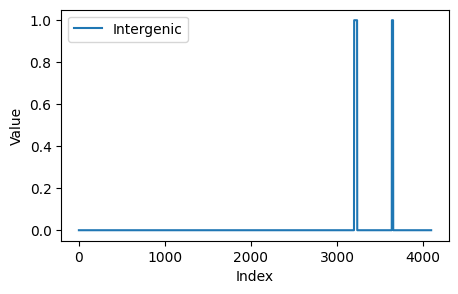

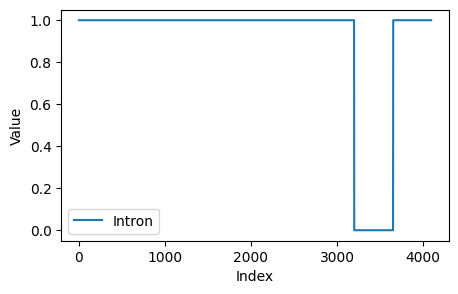

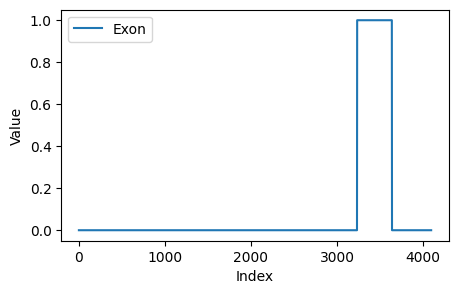

In [111]:
# Create an x-axis for the data
x = np.arange(labels.shape[0])

# Plot each column as a separate line
plt.figure(figsize=(5, 3))  # Optional: Adjust figure size
# for i in range(labels.shape[1]):  # Loop through the columns
#     plt.plot(x, labels[:, i], label=f'Line {i+1}')

plt.plot(x, labels[:, 5], label=f'Intergenic')




# Add labels, legend, and title
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

# Show the plot
plt.show()




# Create an x-axis for the data
x = np.arange(labels.shape[0])

# Plot each column as a separate line
plt.figure(figsize=(5, 3))  # Optional: Adjust figure size
# for i in range(labels.shape[1]):  # Loop through the columns
#     plt.plot(x, labels[:, i], label=f'Line {i+1}')

plt.plot(x, labels[:, 2], label=f'Intron')

# Add labels, legend, and title
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

# Show the plot
plt.show()





# Create an x-axis for the data
x = np.arange(labels.shape[0])

# Plot each column as a separate line
plt.figure(figsize=(5, 3))  # Optional: Adjust figure size
# for i in range(labels.shape[1]):  # Loop through the columns
#     plt.plot(x, labels[:, i], label=f'Line {i+1}')

plt.plot(x, labels[:, 1], label=f'Exon')

# Add labels, legend, and title
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

# Show the plot
plt.show()